<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Radiomics_Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/AIM-Harvard/pyradiomics


In [33]:
import radiomics
from radiomics import featureextractor
import SimpleITK as sitk

from google.colab import drive
import os
import matplotlib.pyplot as plt
import matplotlib.image as pltimg
import numpy as np

In [4]:
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
# unzip the images
!unzip /content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip

In [6]:
path="/content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip"

In [8]:
data_path = ['benign', 'benign_mask', 'malignant', 'malignant_mask']

# check the files and folders
for path in data_path:
  for root, dirs, files in os.walk(path):
    print(f'There are {len(dirs)} directories and  {len(files)} files in "/{root}"')

There are 0 directories and  437 files in "/benign"
There are 0 directories and  455 files in "/benign_mask"
There are 0 directories and  210 files in "/malignant"
There are 0 directories and  212 files in "/malignant_mask"


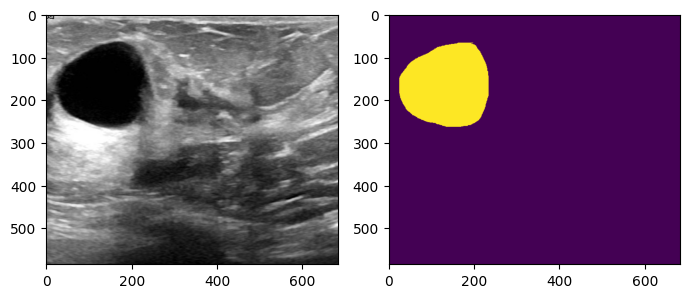

In [9]:
# single image
image_path = "/content/benign/benign (10).png"
mask_path = "/content/benign_mask/benign (10)_mask.png"
img = pltimg.imread(image_path)
mask = pltimg.imread(mask_path)
fix, ax = plt.subplots(1, 2, figsize=(7, 4))
ax[0].imshow(img)
ax[1].imshow(mask)
plt.tight_layout()

**My goal**
| Task                       | Needed Information           |
| -------------------------- | ---------------------------- |
| Shape                      | geometry                     |
| Margin                     | border irregularity          |
| Posterior acoustic pattern | posterior intensity behavior |


1. SHAPE FEATURES (Round / Oval / Irregular)

| Feature                             | Why              |
| ----------------------------------- | ---------------- |
| `original_shape2D_Sphericity`       | roundness        |
| `original_shape_Elongation`         | oval vs round    |
| `original_shape_MajorAxisLength`    | lesion size      |
| `original_shape_MinorAxisLength`    | lesion width     |
| `original_shape2D_Perimeter`        | irregular border |
| `original_shape_SurfaceVolumeRatio` | irregularity     |

2. MARGIN FEATURES (Circumscribed vs Non-circumscribed)

  > Margins are BORDER TEXTURE + EDGE IRREGULARITY.
| Feature                       | Why                  |
| ----------------------------- | -------------------- |
| `original_shape2D_Perimeter`  | rough edges          |
| `original_glcm_Contrast`      | edge sharpness       |
| `original_glcm_Correlation`   | texture organization |
| `original_glszm_ZoneEntropy`  | heterogeneity        |
| `original_ngtdm_Busyness`     | boundary complexity  |
| `original_firstorder_Entropy` | texture randomness   |

3. POSTERIOR ACOUSTIC FEATURES
| Feature                   | Meaning                 |
| ------------------------- | ----------------------- |
| `posterior_mean`          | brightness below lesion |
| `background_mean`         | reference brightness    |
| `posterior_ratio`         | enhancement/shadowing   |
| `posterior_entropy`       | posterior texture       |
| `posterior_glcm_contrast` | posterior variation     |


In [27]:
params = '/content/drive/MyDrive/Healthcare/BUSI/Radiomics-Feature-Extraction/MR_2D_extraction.yaml'
extractor = featureextractor.RadiomicsFeatureExtractor(params)
extractor.enableFeatureClassByName('shape', enabled=True)

region_extractor = featureextractor.RadiomicsFeatureExtractor(params)
region_extractor.enableFeatureClassByName('shape', enabled=True)

region_extractor.settings['force2D'] = True
region_extractor.settings['force2Ddimension'] = 0
region_extractor.settings['resampledPixelSpacing'] = [1, 1]


INFO:radiomics.featureextractor:Loading parameter file /content/drive/MyDrive/Healthcare/BUSI/Radiomics-Feature-Extraction/MR_2D_extraction.yaml
INFO:radiomics.featureextractor:Loading parameter file /content/drive/MyDrive/Healthcare/BUSI/Radiomics-Feature-Extraction/MR_2D_extraction.yaml


In [10]:
# Shape (Round / Oval / Irregular)
shape_features = [
    'original_shape2D_Sphericity',
    'original_shape_Elongation',
    'original_shape_MajorAxisLength',
    'original_shape_MinorAxisLength',
    'original_shape2D_Perimeter',
]

margin_features = [
    'original_firstorder_Entropy',
    'original_glcm_Contrast',
    'original_glcm_Correlation',
    'original_glszm_ZoneEntropy',
    'original_ngtdm_Busyness',
]

posterior_features = [
    'posterior_mean',
    'background_mean',
    'posterior_ratio',
    'original_firstorder_Entropy',
    'original_glcm_Contrast',
    'original_firstorder_Mean',
    'original_firstorder_Variance'
]

In [29]:
# import matplotlib.pyplot as plt
import matplotlib.patches as patches
def plot_lprb(img, xmin, xmax, ymin, ymax, y_end, x1, x2):
  # Copy image for plotting
  plot_img = img[0].copy()

  fig, ax = plt.subplots(figsize=(8,8))

  # Show image
  ax.imshow(plot_img, cmap='gray')

  # Lesion bounding box
  lesion_rect = patches.Rectangle(
      (xmin, ymin),
      xmax - xmin,
      ymax - ymin,
      linewidth=2,
      edgecolor='red',
      facecolor='none',
      label='Lesion'
  )

  # Posterior region
  posterior_rect = patches.Rectangle(
      (xmin, ymax+1),
      xmax - xmin,
      y_end - (ymax+1),
      linewidth=2,
      edgecolor='blue',
      facecolor='none',
      label='Posterior'
  )

  # Background region
  background_rect = patches.Rectangle(
      (x1, ymin),
      x2 - x1,
      ymax - ymin,
      linewidth=2,
      edgecolor='green',
      facecolor='none',
      label='Background'
  )

  # Add rectangles
  ax.add_patch(lesion_rect)
  ax.add_patch(posterior_rect)
  ax.add_patch(background_rect)

  plt.legend()
  plt.title("Lesion, Posterior Region, and Background ROI")
  plt.axis('off')
  plt.show()

In [100]:
def get_image_geometry(img, gray_mask, plot_img=False, offset=80):
  # Get Lesion Bounding Box
  ys, xs = np.where(gray_mask > 0)

  ymin, ymax = ys.min(), ys.max()
  xmin, xmax = xs.min(), xs.max()
  # Define Posterior Region Bellow Lesion

  h, w= img.shape[1:]

  y_end = min(ymax + offset, h)
  # In breast ultrasound, the posterior region means(
  #     the tissue deeper behind the lesion along the ultrasound beam direction.
  # And ultrasound beams usually travel top  →  bottom)
  posterior_region = img[0, ymax+1:y_end, xmin:xmax]

  # comparing the intensity
  if posterior_region.size == 0:
      posterior_mean = 0
  else:
      posterior_mean = posterior_region.mean()

  # Create Background Region --> Area Beside Lesion
  x1 = min(xmax + 10, w)
  x2 = min(xmax + 60, w)
  background_region = img[0, ymin:ymax, x1:x2]
  background_mean = background_region.mean()

  # Posterior Ratio
  posterior_ratio = posterior_mean / background_mean
  # | Ratio | Meaning     |
  # | ----- | ----------- |
  # | < 1   | shadowing   |
  # | > 1   | enhancement |
  if plot_img:
    plot_lprb(img, xmin, xmax, ymin, ymax, y_end, x1, x2)

  return posterior_mean, posterior_ratio, posterior_region, background_mean


In [30]:
def extractur_region_features(region):

    image = sitk.GetImageFromArray(region.astype(np.float32))
    posterior_mask = np.ones(
        region.shape,
        dtype=np.uint8
    )

    mask = sitk.GetImageFromArray(posterior_mask.astype(np.uint8))
     # make geometry identical
    mask.CopyInformation(image)
    mask = sitk.BinaryThreshold(mask, 1, 1, 1, 0)

    results = region_extractor.execute(image, mask)
    required_features = shape_features + margin_features

    return {
        f"posterior_{k}": v for k, v in results.items()
        if k in required_features
    }

In [101]:
def extractur_features(image_apth, mask_path, plot_img=False, offset = 80):
  """
  This method extract features from the given image and mask
  """
  results = {}
  # make sure image is in 8-bit format
  image = sitk.ReadImage(image_path)
  image = sitk.VectorIndexSelectionCast(image, 0)
  image = sitk.JoinSeries(image) # Make sure image is in 2d

  # make sure the mask is in binary format
  mask = sitk.ReadImage(mask_path)
  mask = sitk.BinaryThreshold(mask,
                            lowerThreshold=255,
                            upperThreshold=255,
                            insideValue=1,
                            outsideValue=0)

  # get posterior and background info
  posterior_mean, posterior_ratio, posterior_region, background_mean =  get_image_geometry(
      sitk.GetArrayFromImage(image),
      sitk.GetArrayFromImage(mask),
      plot_img,
      offset)
  # Get the posterio features
  posterior_features = extractur_region_features(posterior_region)

  mask = sitk.JoinSeries(mask)
  required_features = shape_features + margin_features
  results = extractor.execute(image, mask)
  filtered_features = {
    key: value
    for key, value in results.items()
    if key in required_features
  }
  filtered_features['posterior_mean'] = posterior_mean
  filtered_features['posterior_ratio'] = posterior_ratio
  # filtered_features['posterior_region'] = posterior_region
  filtered_features['background_mean'] = background_mean


  return {**filtered_features, **posterior_features}

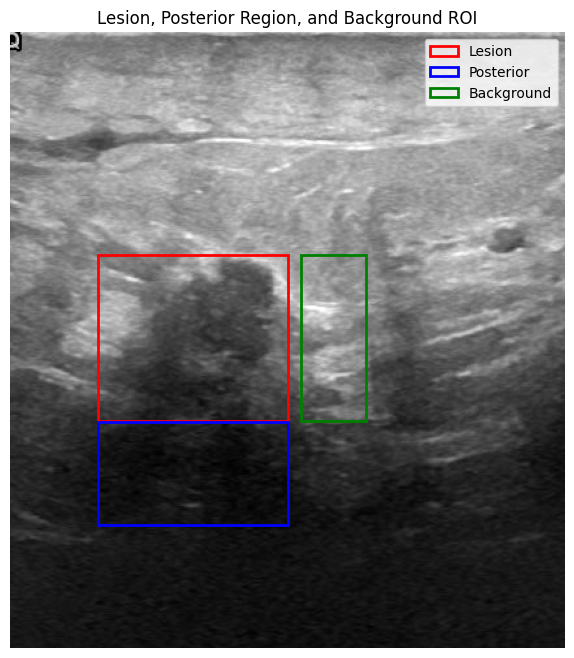

**Build the Langchain agent**

In [ ]:
!pip install -U langchain-openai
!pip install -U langgraph

In [83]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import TypedDict


from dotenv import load_dotenv
# Load environment variable from .env
_ = load_dotenv(override=True)

In [96]:
# Set up the OpenAI GPT model
if "OPENAI_API_KEY" not in os.environ:
    print("OPENAI_API_KEY environment variable is not set.")
    llm = None
else:
    llm = ChatOpenAI(
        model="gpt-5-mini",
        temperature=0
    )
    print("OpenAI Chat model initialized.")

OpenAI Chat model initialized.


In [84]:
# Create states
class GraphState(TypedDict):
    features: dict
    shape_result: str
    margin_result: str
    posterior_result: str
    birads_result: str
    final_report: str

In [85]:
# Shape nodes
def shape_node(state: GraphState):

    prompt = f"""
    Analyze ultrasound lesion shape.

    Features:
    {state['features']}

    Determine:
    - Shape
    - Axis ratio
    - Sphericity interpretation

    Return concise result.
    """

    response = llm.invoke(prompt)

    return {
        "shape_result": response.content
    }

In [86]:
# Margin nodes
def margin_node(state: GraphState):

    prompt = f"""
    Analyze lesion margin.

    Features:
    {state['features']}

    Shape analysis:
    {state['shape_result']}

    Determine:
    - Circumscribed or not
    - Margin suspicion
    """

    response = llm.invoke(prompt)

    return {
        "margin_result": response.content
    }

In [87]:
# Posterior nodes
def posterior_node(state: GraphState):

    prompt = f"""
    Analyze posterior acoustic features.

    Features:
    {state['features']}

    Determine:
    - Shadowing
    - Enhancement
    - No posterior features
    """

    response = llm.invoke(prompt)

    return {
        "posterior_result": response.content
    }

In [88]:
# BI-RADS node
def birads_node(state: GraphState):

    prompt = f"""
    You are a breast ultrasound radiologist.

    Shape:
    {state['shape_result']}

    Margin:
    {state['margin_result']}

    Posterior:
    {state['posterior_result']}

    Assign BI-RADS category with reasoning.
    """

    response = llm.invoke(prompt)

    return {
        "birads_result": response.content
    }

In [89]:
# Report node
def report_node(state: GraphState):

    prompt = f"""
    Generate concise radiology report.

    Shape:
    {state['shape_result']}

    Margin:
    {state['margin_result']}

    Posterior:
    {state['posterior_result']}

    BI-RADS:
    {state['birads_result']}
    """

    response = llm.invoke(prompt)

    return {
        "final_report": response.content
    }

In [90]:
# Build the graph
graph = StateGraph(GraphState)

graph.add_node("shape", shape_node)
graph.add_node("margin", margin_node)
graph.add_node("posterior", posterior_node)
graph.add_node("birads", birads_node)
graph.add_node("report", report_node)

graph.add_edge(START, "shape")
graph.add_edge("shape", "margin")
graph.add_edge("margin", "posterior")
graph.add_edge("posterior", "birads")
graph.add_edge("birads", "report")
graph.add_edge("report", END)

graph = graph.compile()

In [ ]:
random_idx = np.random.randint(0, 210)
# single image
image_path = f"/content/malignant/malignant ({random_idx}).png"
mask_path = f"/content/malignant_mask/malignant ({random_idx})_mask.png"
# Run the graph
image_features = extractur_features(image_path, mask_path, True, 120)

result = graph.invoke({
    "features": image_features
})

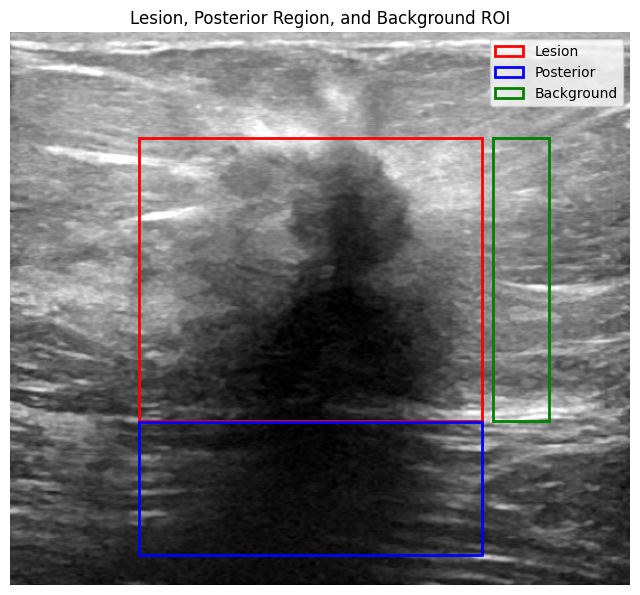

In [104]:
print(result["final_report"])


Exam: Targeted breast ultrasound

Findings
- Single ovoid/elliptical lesion, mildly elongated (axis ratio minor/major ≈ 0.84). Overall margins circumscribed/well‑defined.
- Posterior segmentation is more compact/rounded than the original (sphericity improved from 0.583 → 0.797; perimeter reduced). Original segmentation showed greater irregularity.
- Marked posterior acoustic shadowing: posterior_mean/background_mean ≈ 0.228 with accompanying texture changes consistent with attenuation (reduced contrast, zone entropy, and busyness).

Impression
1. Ovoid, circumscribed mass with marked posterior acoustic shadowing — suspicious feature despite otherwise benign shape.  
2. Discordance between original (more irregular) and posterior (more rounded/homogeneous) segmentations noted. Correlate with mammography/clinical exam for calcification or architectural distortion.

Assessment and recommendation
- BI-RADS 4A (low suspicion for malignancy). Recommend ultrasound‑guided core needle biopsy for